# Fraud Detection Rule Grid Search

Simple and efficient grid search for fraud detection rules.

## Features
- ✅ Customizable parameter ranges
- ✅ Clean progress bar (tqdm/ipywidgets)
- ✅ Auto-save after each query to JSON
- ✅ Auto-resume from interruptions
- ✅ Results in pandas DataFrame
- ✅ Export to CSV/Excel

## Quick Start

1. **Configure parameters** in Section 3
2. **Run grid search** in Section 5
3. **View results** - automatically displayed

## Managing Results

```python
# Check progress
view_progress()

# Start fresh (deletes saved results)
clear_results()

# Export to CSV
export_results_csv()
```

## How It Works

- Results saved to `grid_results.json` after each query
- If interrupted, just re-run - it skips completed combinations
- No data loss, even if kernel crashes

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from clickhouse_driver import Client
from itertools import product
from datetime import datetime
import time
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Configure ClickHouse Connection

In [2]:
# ClickHouse connection parameters
CLICKHOUSE_HOST = 'localhost'
CLICKHOUSE_PORT = 9000
CLICKHOUSE_USER = 'default'
CLICKHOUSE_PASSWORD = 'DfsTeChB1'
CLICKHOUSE_DATABASE = 'public'

# Test connection
try:
    client = Client(
        host=CLICKHOUSE_HOST,
        port=CLICKHOUSE_PORT,
        user=CLICKHOUSE_USER,
        password=CLICKHOUSE_PASSWORD,
        database=CLICKHOUSE_DATABASE
    )
    version = client.execute('SELECT version()')[0][0]
    print(f"✅ Connected to ClickHouse version: {version}")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Connected to ClickHouse version: 25.10.1.3796


## 3. Define Grid Search Parameters

### 🔧 CUSTOMIZE YOUR PARAMETERS HERE

In [3]:
# ============================================================================
# PARAMETER RANGES - Edit these to test different values
# ============================================================================

grid_params = {
    # Account pre-filter thresholds (PKR)
    'prefilter': [ 1000, 1500, 2000, 3000, 5000],
    
    # Velocity thresholds (transactions per hour)
    'velocity': [ 3, 5, 8, 10],
    
    # Spike multipliers (times historical max)
    'spike': [3, 4, 5],
    
    # Lookback periods (months)
    'lookback': [1, 2]
}

# ============================================================================
# DATE RANGES
# ============================================================================

date_config = {
    # Training/Pre-filter period (to calculate account history)
    'prefilter_start_date': '2025-06-01',
    'prefilter_end_date': '2025-06-30',
    
    # Test period (to evaluate rules)
    'test_start_date': '2025-07-01',
    'test_end_date': '2025-07-31'
}

# Calculate total combinations
total_combinations = np.prod([len(v) for v in grid_params.values()])
print(f"📊 Total parameter combinations: {total_combinations}")
print(f"📅 Training period: {date_config['prefilter_start_date']} to {date_config['prefilter_end_date']}")
print(f"📅 Test period: {date_config['test_start_date']} to {date_config['test_end_date']}")
print(f"\n⚠️ Estimated time: ~{total_combinations * 2} seconds ({total_combinations * 2 / 60:.1f} minutes)")

📊 Total parameter combinations: 120
📅 Training period: 2025-06-01 to 2025-06-30
📅 Test period: 2025-07-01 to 2025-07-31

⚠️ Estimated time: ~240 seconds (4.0 minutes)


## 4. Define Query Template

In [4]:
def build_query(prefilter, velocity, spike, lookback, date_config):
    """
    Build ClickHouse query for a specific parameter combination.
    
    Parameters:
    -----------
    prefilter : int
        Account pre-filter threshold (PKR)
    velocity : int
        Velocity threshold (transactions per hour)
    spike : int
        Spike multiplier (times historical max)
    lookback : int
        Lookback period in months (1, 2, or 3)
    date_config : dict
        Dictionary containing date range configurations
    
    Returns:
    --------
    str : ClickHouse SQL query
    """
    
    query = f"""
    WITH 
    -- Account history from training period
    account_profiles AS (
        SELECT 
            ac_from,
            max(trx_amt) AS max_hist_amt,
            count(*) AS txn_count_hist
        FROM public.stixor_fraud_features_distributed
        WHERE cutoff_date BETWEEN '{date_config['prefilter_start_date']}' AND '{date_config['prefilter_end_date']}'
          AND mbar_account_type_name = 'Customer Account'
        GROUP BY ac_from
    ),
    
    -- Calculate transaction features
    transaction_data AS (
        SELECT 
            t.trans_id,
            t.fraud_flag,
            t.ac_from,
            t.trx_amt,
            t.trans_initiate_time,
            ap.max_hist_amt,
            ap.txn_count_hist,
            
            -- Velocity (transactions in last hour)
            COUNT(*) OVER (
                PARTITION BY t.ac_from 
                ORDER BY toUnixTimestamp(t.trans_initiate_time) ASC 
                RANGE BETWEEN 3600 PRECEDING AND CURRENT ROW
            ) AS velocity_1h,
            
            -- Historical maximums for different lookback periods
            MAX(t.trx_amt) OVER (
                PARTITION BY t.ac_from 
                ORDER BY toUnixTimestamp(t.trans_initiate_time)
                ROWS BETWEEN 30 PRECEDING AND 1 PRECEDING
            ) AS max_1m,
            
            MAX(t.trx_amt) OVER (
                PARTITION BY t.ac_from 
                ORDER BY toUnixTimestamp(t.trans_initiate_time)
                ROWS BETWEEN 60 PRECEDING AND 1 PRECEDING
            ) AS max_2m,
            
            MAX(t.trx_amt) OVER (
                PARTITION BY t.ac_from 
                ORDER BY toUnixTimestamp(t.trans_initiate_time)
                ROWS BETWEEN 90 PRECEDING AND 1 PRECEDING
            ) AS max_3m
            
        FROM public.stixor_fraud_features_distributed t
        GLOBAL LEFT JOIN account_profiles ap ON t.ac_from = ap.ac_from
        WHERE t.cutoff_date BETWEEN '{date_config['test_start_date']}' AND '{date_config['test_end_date']}'
          AND t.mbar_account_type_name = 'Customer Account'
    ),
    
    -- Apply rule
    rule_evaluation AS (
        SELECT 
            trans_id,
            fraud_flag,
            (
                max_hist_amt < {prefilter}
                AND velocity_1h > {velocity}
                AND (
                    ({lookback} = 1 AND trx_amt > {spike} * max_1m) OR
                    ({lookback} = 2 AND trx_amt > {spike} * max_2m) OR
                    ({lookback} = 3 AND trx_amt > {spike} * max_3m)
                )
            ) AS rule_triggered
        FROM transaction_data
    )
    
    -- Calculate metrics
    SELECT 
        {prefilter} AS max_hist_amt_threshold,
        {velocity} AS velocity_threshold,
        {spike} AS spike_multiplier,
        {lookback} AS lookback_months,
        
        countIf(rule_triggered AND fraud_flag = 1) AS true_positives,
        countIf(rule_triggered AND fraud_flag = 0) AS false_positives,
        countIf(NOT rule_triggered AND fraud_flag = 1) AS false_negatives,
        countIf(rule_triggered) AS total_alerts,
        
        round(
            countIf(rule_triggered AND fraud_flag = 1) * 100.0 / 
            nullIf(countIf(rule_triggered), 0), 
            4
        ) AS precision_pct,
        
        round(
            countIf(rule_triggered AND fraud_flag = 1) * 100.0 / 
            nullIf(countIf(fraud_flag = 1), 0), 
            4
        ) AS recall_pct,
        
        round(
            2.0 * countIf(rule_triggered AND fraud_flag = 1) / 
            nullIf(countIf(rule_triggered) + countIf(fraud_flag = 1), 0) * 100, 
            4
        ) AS f1_score,
        
        round(
            countIf(rule_triggered) * 1.0 / 
            nullIf(countIf(rule_triggered AND fraud_flag = 1), 0), 
            1
        ) AS alert_to_fraud_ratio
        
    FROM rule_evaluation
    HAVING total_alerts > 0
    """
    
    return query

print("✅ Query template defined")

✅ Query template defined


## 5. Run Grid Search

### Execute queries for all parameter combinations

In [5]:
import json
import os

def run_grid_search(client, grid_params, date_config, results_file='grid_results.json'):
    """
    Execute grid search across all parameter combinations.
    Saves results after each query to JSON file.
    """
    
    # Load existing results if file exists
    if os.path.exists(results_file):
        print(f"📂 Loading existing results from: {results_file}")
        with open(results_file, 'r') as f:
            data = json.load(f)
            all_results = data.get('results', [])
            completed = set(tuple(r[:4]) for r in all_results)  # First 4 values are params
        print(f"✅ Found {len(all_results)} completed combinations\n")
    else:
        all_results = []
        completed = set()
    
    # Generate all parameter combinations
    param_combinations = list(product(
        grid_params['prefilter'],
        grid_params['velocity'],
        grid_params['spike'],
        grid_params['lookback']
    ))
    
    # Filter to only remaining combinations
    remaining = [(p, v, s, l) for p, v, s, l in param_combinations 
                 if (p, v, s, l) not in completed]
    
    print(f"📊 Total combinations: {len(param_combinations)}")
    print(f"✅ Already completed: {len(completed)}")
    print(f"⏳ Remaining: {len(remaining)}\n")
    
    if not remaining:
        print("🎉 All combinations already completed!")
        return load_results_as_dataframe(all_results)
    
    # Process remaining combinations with progress bar
    print(f"🚀 Starting grid search...\n")
    start_time = time.time()
    
    # Create progress bar with explicit display
    pbar = tqdm(remaining, desc="🔍 Processing", unit="combo", 
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    
    for prefilter, velocity, spike, lookback in pbar:
        try:
            # Update progress bar description with current params
            pbar.set_description(f"🔍 P:{prefilter} V:{velocity} S:{spike} L:{lookback}")
            
            # Build and execute query
            query = build_query(prefilter, velocity, spike, lookback, date_config)
            result = client.execute(query)
            
            # Save result if we got data
            if result:
                all_results.append(result[0])
                
                # Save to file after each query
                with open(results_file, 'w') as f:
                    json.dump({
                        'results': all_results,
                        'total': len(param_combinations),
                        'completed': len(all_results),
                        'last_updated': datetime.now().isoformat()
                    }, f, indent=2, default=str)
                    
        except Exception as e:
            pbar.write(f"⚠️ Error [P:{prefilter} V:{velocity} S:{spike} L:{lookback}]: {str(e)[:100]}")
            continue
    
    pbar.close()
    
    elapsed = time.time() - start_time
    print(f"\n✅ Grid search completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"📊 Total successful: {len(all_results)}/{len(param_combinations)}")
    print(f"💾 Results saved to: {results_file}\n")
    
    return load_results_as_dataframe(all_results)


def load_results_as_dataframe(results):
    """Convert results list to DataFrame with quality tiers."""
    if not results:
        return None
    
    columns = [
        'max_hist_amt_threshold', 'velocity_threshold', 'spike_multiplier', 
        'lookback_months', 'true_positives', 'false_positives', 
        'false_negatives', 'total_alerts', 'precision_pct', 
        'recall_pct', 'f1_score', 'alert_to_fraud_ratio'
    ]
    df = pd.DataFrame(results, columns=columns)
    
    # Add quality tier
    def get_quality_tier(row):
        if row['true_positives'] == 0:
            return '❌ No Fraud'
        elif row['precision_pct'] >= 0.04:
            return '🏆 Excellent'
        elif row['precision_pct'] >= 0.025:
            return '✨ Very Good'
        elif row['precision_pct'] >= 0.015:
            return '👍 Good'
        elif row['precision_pct'] >= 0.01:
            return '📊 Fair'
        else:
            return '⚠️ Poor'
    
    df['quality_tier'] = df.apply(get_quality_tier, axis=1)
    
    # Sort and rank
    df = df.sort_values(['f1_score', 'precision_pct', 'true_positives'], 
                        ascending=[False, False, False]).reset_index(drop=True)
    df.insert(0, 'rank', range(1, len(df) + 1))
    
    return df


# Run the grid search
df_results = run_grid_search(client, grid_params, date_config)

if df_results is not None:
    print(f"📈 Top 10 Results:")
    display(df_results.head(10))

📂 Loading existing results from: grid_results.json
✅ Found 120 completed combinations

📊 Total combinations: 120
✅ Already completed: 120
⏳ Remaining: 0

🎉 All combinations already completed!
📈 Top 10 Results:


,rank,max_hist_amt_threshold,velocity_threshold,spike_multiplier,lookback_months,true_positives,false_positives,false_negatives,total_alerts,precision_pct,recall_pct,f1_score,alert_to_fraud_ratio,quality_tier
0,1,1500,8,4,2,4,2955,5370,2959,0.1352,0.0744,0.0960,739.8,🏆 Excellent
1,2,2000,8,4,2,4,3163,5370,3167,0.1263,0.0744,0.0937,791.8,🏆 Excellent
2,3,3000,8,4,2,4,3627,5370,3631,0.1102,0.0744,0.0888,907.8,🏆 Excellent
3,4,1500,8,4,1,4,3732,5370,3736,0.1071,0.0744,0.0878,934.0,🏆 Excellent
4,5,1500,8,3,2,4,3799,5370,3803,0.1052,0.0744,0.0872,950.8,🏆 Excellent
5,6,2000,8,4,1,4,4039,5370,4043,0.0989,0.0744,0.0850,1010.8,🏆 Excellent
6,7,1500,10,4,2,3,1688,5371,1691,0.1774,0.0558,0.0849,563.7,🏆 Excellent
7,8,2000,8,3,2,4,4075,5370,4079,0.0981,0.0744,0.0846,1019.8,🏆 Excellent
8,9,2000,10,4,2,3,1802,5371,1805,0.1662,0.0558,0.0836,601.7,🏆 Excellent
9,10,5000,8,4,2,4,4190,5370,4194,0.0954,0.0744,0.0836,1048.5,🏆 Excellent


In [10]:
df_results.sort_values('true_positives', ascending=False)

,rank,max_hist_amt_threshold,velocity_threshold,spike_multiplier,lookback_months,true_positives,false_positives,false_negatives,total_alerts,precision_pct,recall_pct,f1_score,alert_to_fraud_ratio,quality_tier
65,66,3000,3,3,1,10,56234,5364,56244,0.0178,0.1861,0.0325,5624.4,👍 Good
68,69,5000,3,3,2,10,58726,5364,58736,0.0170,0.1861,0.0312,5873.6,👍 Good
69,70,5000,3,3,1,10,66654,5364,66664,0.0150,0.1861,0.0278,6666.4,👍 Good
61,62,3000,3,3,2,10,50258,5364,50268,0.0199,0.1861,0.0359,5026.8,👍 Good
60,61,2000,3,3,2,9,43682,5365,43691,0.0206,0.1675,0.0367,4854.6,👍 Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,116,2000,10,5,2,0,1405,5374,1405,0.0000,0.0000,0.0000,NaN,❌ No Fraud
116,117,3000,10,5,1,0,2190,5374,2190,0.0000,0.0000,0.0000,NaN,❌ No Fraud
117,118,3000,10,5,2,0,1619,5374,1619,0.0000,0.0000,0.0000,NaN,❌ No Fraud
118,119,5000,10,5,1,0,2574,5374,2574,0.0000,0.0000,0.0000,NaN,❌ No Fraud


## 6. Analyze Results

### Summary Statistics

## 5.1 Checkpoint Management Utilities

Utilities to inspect and manage checkpoint files

In [6]:
def view_progress(results_file='grid_results.json'):
    """View current progress of grid search."""
    if not os.path.exists(results_file):
        print(f"❌ No results file found: {results_file}")
        return
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    print("="*60)
    print("GRID SEARCH PROGRESS")
    print("="*60)
    completed = data.get('completed', 0)
    total = data.get('total', 0)
    pct = (completed/total*100) if total > 0 else 0
    
    print(f"Progress: {completed}/{total} ({pct:.1f}%)")
    print(f"Last updated: {data.get('last_updated', 'Unknown')}")
    print(f"Results file: {results_file}")
    print("="*60)


def clear_results(results_file='grid_results.json'):
    """Delete results file to start fresh."""
    if os.path.exists(results_file):
        os.remove(results_file)
        print(f"✅ Deleted: {results_file}")
        print(f"🔄 Next run will start from scratch")
    else:
        print(f"❌ File not found: {results_file}")


def export_results_csv(results_file='grid_results.json'):
    """Export results to CSV."""
    if not os.path.exists(results_file):
        print(f"❌ No results file found: {results_file}")
        return
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    df = load_results_as_dataframe(data.get('results', []))
    if df is not None:
        filename = f"grid_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        df.to_csv(filename, index=False)
        print(f"✅ Exported {len(df)} results to: {filename}")
    else:
        print("❌ No results to export")


# Quick commands:
# view_progress()          # Check current progress
# clear_results()          # Start fresh
# export_results_csv()     # Export to CSV

print("✅ Utilities loaded")

✅ Utilities loaded


## 5.2 Debug & Monitor Running Search

Quick debugging tools to check if the search is running properly

In [ ]:
# Test ClickHouse connection
def test_connection():
    """Quick test to verify ClickHouse is working."""
    try:
        print("🔍 Testing ClickHouse...")
        result = client.execute("SELECT 1")
        print(f"✅ Connection OK")
        
        result = client.execute("SELECT COUNT(*) FROM public.stixor_fraud_features_distributed LIMIT 1")
        print(f"✅ Data accessible: {result[0][0]:,} rows")
        return True
    except Exception as e:
        print(f"❌ Error: {e}")
        return False

# Uncomment to test:
# test_connection()

print("✅ Test utility loaded")

✅ Debug utilities loaded


In [ ]:
# ? Quick Diagnostic - Run this if something seems wrong

print("="*60)
print("DIAGNOSTIC CHECK")
print("="*60)

# 1. Check results file
print("\n1️⃣ Results File:")
if os.path.exists('grid_results.json'):
    with open('grid_results.json', 'r') as f:
        data = json.load(f)
    print(f"   ✅ Found: {data.get('completed', 0)}/{data.get('total', 0)} completed")
    if data.get('completed', 0) >= data.get('total', 0):
        print(f"   ⚠️  ALL DONE! Run clear_results() to start fresh")
else:
    print(f"   ℹ️  No file (first run)")

# 2. ClickHouse connection
print("\n2️⃣ ClickHouse:")
try:
    client.execute("SELECT 1")
    print(f"   ✅ Connected")
except Exception as e:
    print(f"   ❌ Error: {str(e)[:50]}")

# 3. Parameters
print("\n3️⃣ Parameters:")
total = np.prod([len(v) for v in grid_params.values()])
print(f"   Total combinations: {total}")

print("\n" + "="*60)
print("💡 TIP: Run clear_results() to delete progress and start over")
print("="*60)

In [ ]:
if df_results is not None:
    print("="*70)
    print("GRID SEARCH SUMMARY")
    print("="*70)
    
    print(f"\n📊 Results: {len(df_results)} combinations")
    print(f"📅 Period: {date_config['test_start_date']} to {date_config['test_end_date']}")
    
    print(f"\n🏆 Quality Tiers:")
    for tier, count in df_results['quality_tier'].value_counts().items():
        print(f"   {tier}: {count}")
    
    print(f"\n🎯 Best Configuration:")
    best = df_results.iloc[0]
    print(f"   Params: P={best['max_hist_amt_threshold']} V={best['velocity_threshold']} "
          f"S={best['spike_multiplier']} L={best['lookback_months']}")
    print(f"   Precision: {best['precision_pct']:.4f}%")
    print(f"   Recall: {best['recall_pct']:.4f}%")
    print(f"   F1: {best['f1_score']:.4f}")
    print(f"   Quality: {best['quality_tier']}")
    print("="*70)

## 7. Visualize Results

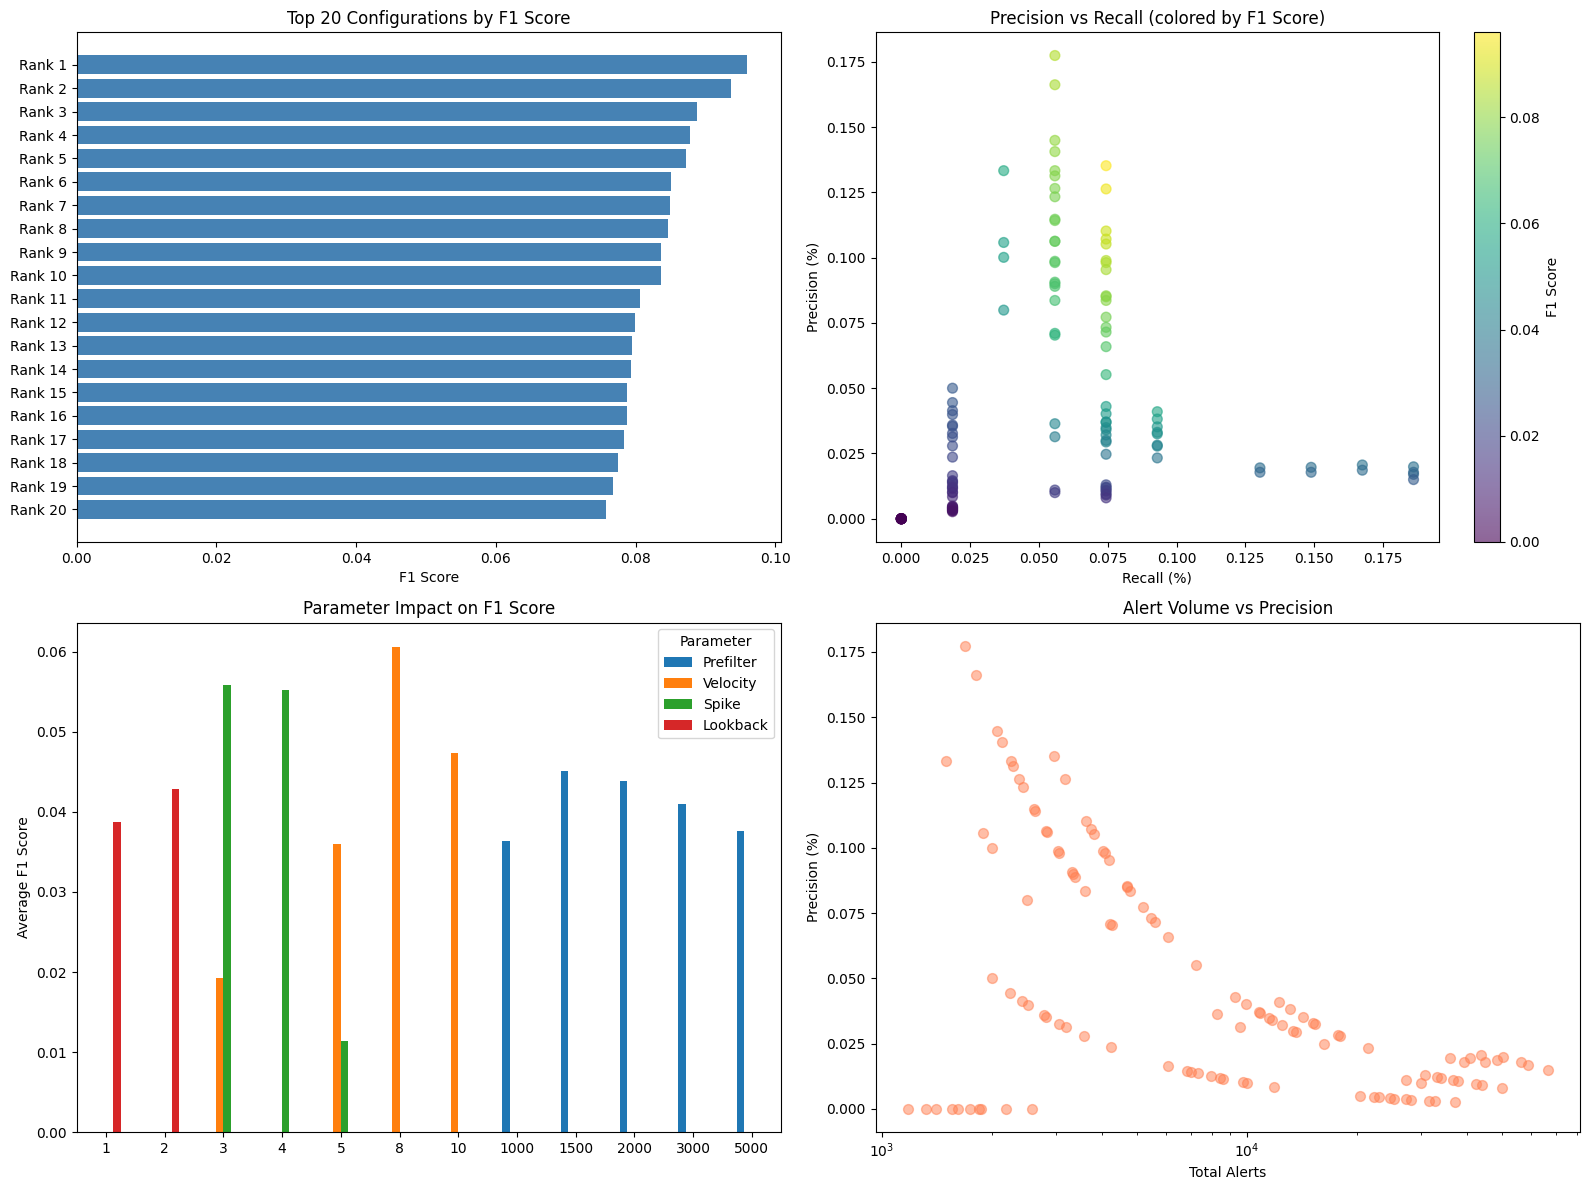

✅ Visualizations generated


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

if df_results is not None and len(df_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Top 20 F1 Scores
    top20 = df_results.head(20)
    ax1 = axes[0, 0]
    ax1.barh(range(len(top20)), top20['f1_score'], color='steelblue')
    ax1.set_yticks(range(len(top20)))
    ax1.set_yticklabels([f"Rank {i+1}" for i in range(len(top20))])
    ax1.set_xlabel('F1 Score')
    ax1.set_title('Top 20 Configurations by F1 Score')
    ax1.invert_yaxis()
    
    # 2. Precision vs Recall
    ax2 = axes[0, 1]
    scatter = ax2.scatter(
        df_results['recall_pct'], 
        df_results['precision_pct'],
        c=df_results['f1_score'],
        cmap='viridis',
        alpha=0.6,
        s=50
    )
    ax2.set_xlabel('Recall (%)')
    ax2.set_ylabel('Precision (%)')
    ax2.set_title('Precision vs Recall (colored by F1 Score)')
    plt.colorbar(scatter, ax=ax2, label='F1 Score')
    
    # 3. Parameter Impact on F1 Score
    ax3 = axes[1, 0]
    param_impact = pd.DataFrame({
        'Prefilter': df_results.groupby('max_hist_amt_threshold')['f1_score'].mean(),
        'Velocity': df_results.groupby('velocity_threshold')['f1_score'].mean(),
        'Spike': df_results.groupby('spike_multiplier')['f1_score'].mean(),
        'Lookback': df_results.groupby('lookback_months')['f1_score'].mean()
    })
    param_impact.plot(kind='bar', ax=ax3, rot=0)
    ax3.set_ylabel('Average F1 Score')
    ax3.set_title('Parameter Impact on F1 Score')
    ax3.legend(title='Parameter')
    
    # 4. Alert Volume vs Precision
    ax4 = axes[1, 1]
    ax4.scatter(
        df_results['total_alerts'],
        df_results['precision_pct'],
        alpha=0.5,
        s=50,
        c='coral'
    )
    ax4.set_xlabel('Total Alerts')
    ax4.set_ylabel('Precision (%)')
    ax4.set_title('Alert Volume vs Precision')
    ax4.set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizations generated")

## 8. Export Results

In [ ]:
if df_results is not None:
    # Generate timestamp for filenames
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Export to CSV
    csv_filename = f'grid_search_results_{timestamp}.csv'
    df_results.to_csv(csv_filename, index=False)
    print(f"✅ Results exported to: {csv_filename}")
    
    # Export top 100 to Excel with formatting
    excel_filename = f'grid_search_top100_{timestamp}.xlsx'
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        df_results.head(100).to_excel(writer, sheet_name='Top 100', index=False)
        
        if df_failed is not None and len(df_failed) > 0:
            df_failed.to_excel(writer, sheet_name='Failed', index=False)
    
    print(f"✅ Top 100 results exported to: {excel_filename}")
    
    # Display summary
    print(f"\n📊 Files created:")
    print(f"   • {csv_filename} (all results)")
    print(f"   • {excel_filename} (top 100 + failed)")
else:
    print("❌ No results to export")

## 9. Interactive Filtering

Filter results by quality tier or specific parameter ranges

In [ ]:
if df_results is not None:
    # Filter by quality tier
    quality_filter = '🏆 Excellent'  # Change this to filter by different tiers
    
    filtered = df_results[df_results['quality_tier'] == quality_filter]
    
    print(f"🔍 Filtering by: {quality_filter}")
    print(f"📊 Found {len(filtered)} combinations\n")
    
    if len(filtered) > 0:
        display(filtered.head(20))
    else:
        print("No results found for this filter. Available tiers:")
        print(df_results['quality_tier'].unique())

In [ ]:
if df_results is not None:
    # Advanced filtering - customize these conditions
    advanced_filter = df_results[
        (df_results['precision_pct'] >= 0.025) &  # Minimum 0.025% precision
        (df_results['recall_pct'] >= 10) &         # Minimum 10% recall
        (df_results['total_alerts'] < 50000)       # Maximum 50k alerts
    ]
    
    print(f"🔍 Advanced Filter Results:")
    print(f"   Precision >= 0.025%")
    print(f"   Recall >= 10%")
    print(f"   Total Alerts < 50,000")
    print(f"\n📊 Found {len(advanced_filter)} combinations\n")
    
    if len(advanced_filter) > 0:
        display(advanced_filter)

## 10. Quick Insights

Get quick insights about parameter patterns in top performers

In [ ]:
if df_results is not None:
    print("="*80)
    print("PARAMETER PATTERNS IN TOP 20 PERFORMERS")
    print("="*80)
    
    top20 = df_results.head(20)
    
    print(f"\n🎯 Most Common Values in Top 20:")
    print(f"\n   Prefilter Threshold:")
    print(top20['max_hist_amt_threshold'].value_counts().head(3))
    
    print(f"\n   Velocity Threshold:")
    print(top20['velocity_threshold'].value_counts().head(3))
    
    print(f"\n   Spike Multiplier:")
    print(top20['spike_multiplier'].value_counts().head(3))
    
    print(f"\n   Lookback Period:")
    print(top20['lookback_months'].value_counts().head(3))
    
    print(f"\n📈 Average Values in Top 20:")
    print(f"   Prefilter: {top20['max_hist_amt_threshold'].mean():.0f} PKR")
    print(f"   Velocity: {top20['velocity_threshold'].mean():.1f} txn/hour")
    print(f"   Spike: {top20['spike_multiplier'].mean():.1f}x")
    print(f"   Lookback: {top20['lookback_months'].mean():.1f} months")

## 💡 Next Steps

1. **Analyze Results**: Review the top performing combinations above
2. **Refine Search**: Narrow down parameter ranges around best performers
3. **Validate**: Test top rules on different time periods (e.g., August data)
4. **Export**: Save results using the export cell above
5. **Deploy**: Implement the best rule in production

## 🔄 Re-running the Search

To run a new search:
1. Go back to **Section 3** and modify parameters
2. Re-run from **Section 5** onwards
3. Compare results across different configurations

## 11. Advanced: Running Multiple Experiments with Different Checkpoints

Run different parameter configurations in parallel by using different checkpoint files

In [ ]:
# Example: Run different experiments with separate checkpoint files

# Experiment 1: Low thresholds
experiment1_params = {
    'prefilter': [500, 1000, 1500],
    'velocity': [2, 3, 4],
    'spike': [2, 3],
    'lookback': [1, 2]
}

# Experiment 2: High thresholds
experiment2_params = {
    'prefilter': [3000, 5000, 10000],
    'velocity': [5, 6, 7],
    'spike': [4, 5],
    'lookback': [2, 3]
}

# Run experiments with different checkpoint files
# Uncomment the one you want to run:

# df_exp1, df_failed1 = run_grid_search(
#     client, 
#     experiment1_params, 
#     date_config, 
#     checkpoint_file='experiment1_checkpoint.json'
# )

# df_exp2, df_failed2 = run_grid_search(
#     client, 
#     experiment2_params, 
#     date_config, 
#     checkpoint_file='experiment2_checkpoint.json'
# )

# Check status of different experiments
# inspect_checkpoint('experiment1_checkpoint.json')
# inspect_checkpoint('experiment2_checkpoint.json')

print("💡 Tip: Use different checkpoint files to run separate experiments")
print("   This allows you to:")
print("   - Test different parameter ranges independently")
print("   - Resume specific experiments without affecting others")
print("   - Compare results across different strategies")